<h2 align=center>Exploratory Data Analysis With Python and Pandas</h2>

### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calmap

### Context

The growth of supermarkets in most populated cities are increasing and market competitions are also high. The dataset is one of the historical sales of supermarket company which has recorded in 3 different branches for 3 months data.

**Data Dictionary**

1. ***Invoice id:*** Computer generated sales slip invoice identification number

2. ***Branch:*** Branch of supercenter (3 branches are available identified by A, B and C).

3. ***City:*** Location of supercenters

4. ***Customer type:*** Type of customers, recorded by Members for customers using member card and Normal for without member card.

5. ***Gender:*** Gender type of customer

6. ***Product line:*** General item categorization groups - Electronic accessories, Fashion accessories, Food and beverages, Health and beauty, Home and lifestyle, Sports and travel

7. ***Unit price:*** Price of each product in USD

8. ***Quantity:*** Number of products purchased by customer

9. ***Tax:*** 5% tax fee for customer buying

10. ***Total:*** Total price including tax

11. ***Date:*** Date of purchase (Record available from January 2019 to March 2019)

12. ***Time:*** Purchase time (10am to 9pm)

13. ***Payment:*** Payment used by customer for purchase (3 methods are available – Cash, Credit card and Ewallet)

14. ***COGS:*** Cost of goods sold

15. ***Gross margin percentage:*** Gross margin percentage

16. ***Gross income:*** Gross income

17. ***Rating:*** Customer stratification rating on their overall shopping experience (On a scale of 1 to 10)

---

Link to data source: https://www.kaggle.com/aungpyaeap/supermarket-sales

### Task 1: Initial Data Exploration

In [2]:
df = pd.read_csv('supermarket_sales.csv')

In [3]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/19,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [4]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [5]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                   float64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\avikd\AppData\Local\Temp\ipykernel_18880\2394721818.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df.dtypes

Invoice ID                         object
Branch                             object
City                               object
Customer type                      object
Gender                             object
Product line                       object
Unit price                        float64
Quantity                          float64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [8]:
df.set_index('Date', inplace = True)

In [9]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Time,Payment,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,,,,,,,,,
2019-01-05,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,13:08,Ewallet,522.83,4.761905,26.1415,9.1
2019-03-08,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,10:29,Cash,76.40,4.761905,3.8200,9.6
2019-03-03,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,13:23,Credit card,324.31,4.761905,16.2155,7.4
2019-01-27,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,20:33,Ewallet,465.76,4.761905,23.2880,8.4
2019-02-08,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,10:37,Ewallet,604.17,4.761905,30.2085,5.3


### Task 2: Univariate Analysis

**Question 1:** What does the distribution of customer ratings looks like? Is it skewed?

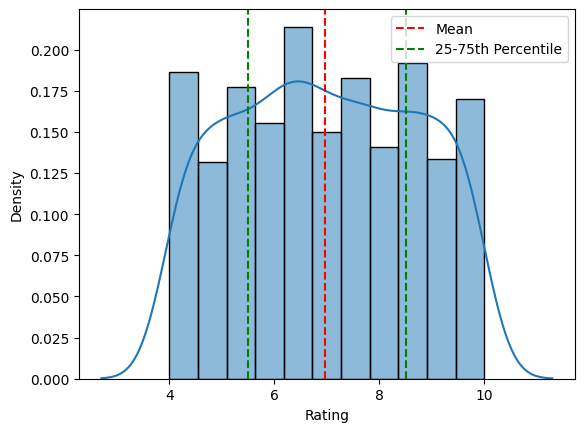

In [10]:
sns.histplot(df['Rating'], kde = True, stat = 'density', kde_kws=dict(cut=3))
plt.axvline(x = np.mean(df['Rating']), c = 'r', ls = '--', label = 'Mean')
plt.axvline(x = np.percentile(df['Rating'], 25), c = 'green', ls = '--', label = '25-75th Percentile')
plt.axvline(x = np.percentile(df['Rating'], 75), c = 'green', ls = '--')
plt.legend()
plt.show()

**Observations:**
- The distribution of user ratings looks relatively uniform.
- There doesn't seem to be any skew in the left or right direction.

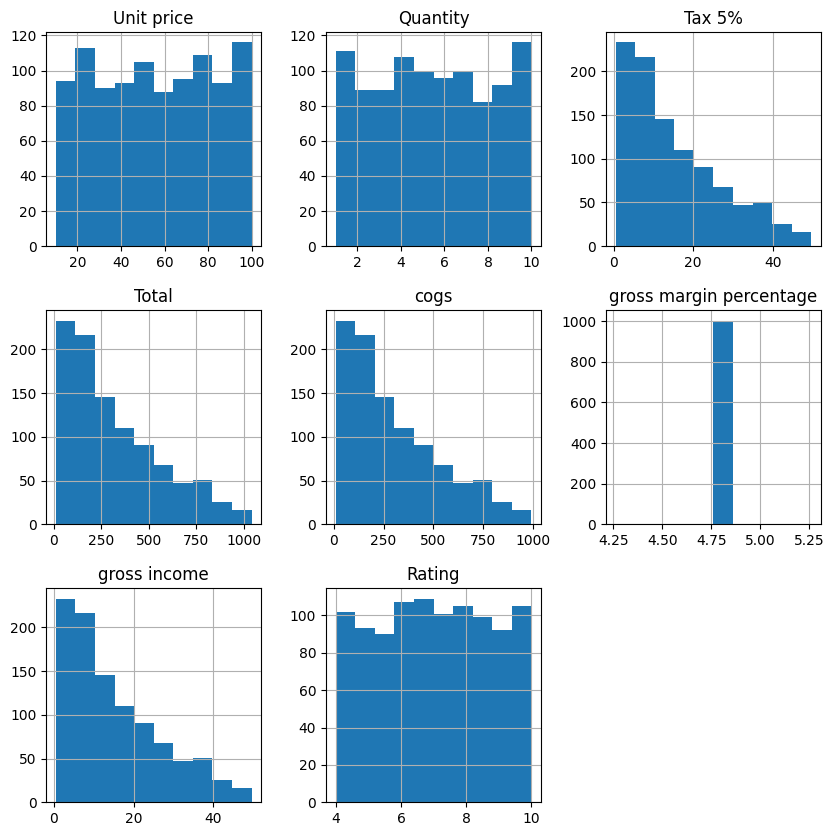

In [11]:
df.hist(figsize = (10,10))
plt.show()

**Observations:**
- **Unit Price** and **Quantity** are uniformly distributed.
- **Tax** has a right skew, which means most of the tax collected falls between 0 and 20, but there are a few cases where it's over 40.
- The **Gross Margin Percentage** is a constant value, which is why it doesn't have much of a distribution to it.
- The **COGS** (Cost of goods sold), **Total**, and **Gross Income** are highly correlated variables, so they all followed almost identical distributions.
- The **User Rating** has a uniform distribution.

**Question 2:** Do aggregate sales numbers differ by much between branches?

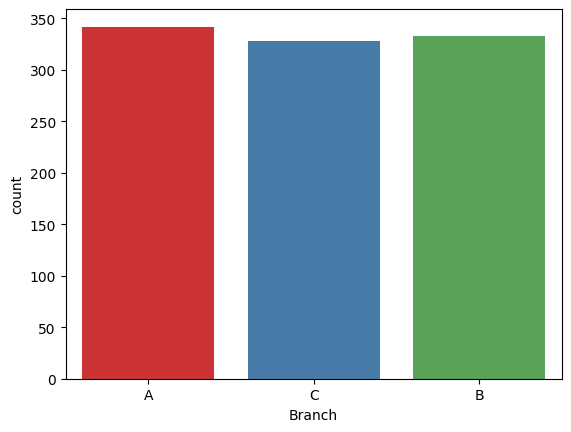

In [12]:
sns.countplot(x=df['Branch'], hue=df['Branch'], palette='Set1', legend=False)
plt.show()

In [13]:
df['Branch'].value_counts()

Branch
A    342
B    333
C    328
Name: count, dtype: int64

**Observation:**
- **A** has 342 sales, **B** has 333 sales, and **C** has 328 sales.
- So, aggregate sales numbers don't differ by much between branches.

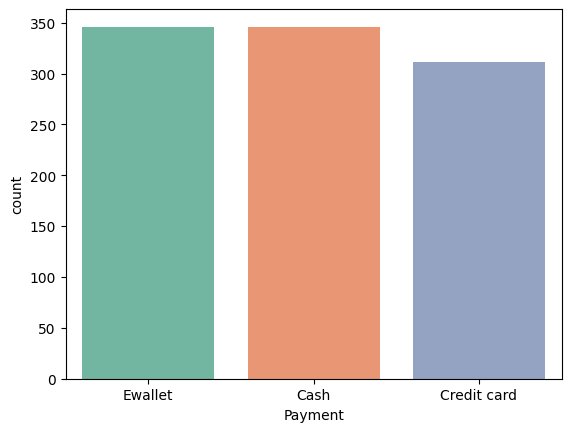

In [14]:
sns.countplot(x=df['Payment'], hue=df['Payment'], palette='Set2', legend=False)
plt.show()

**Observation:**
- Ewallet is the most popular form of payment for customers.
- Credit Card is the least popular form of payment.

### Task 3: Bivariate Analysis

**Question 3:** Is there a relationship between gross income and customer ratings?

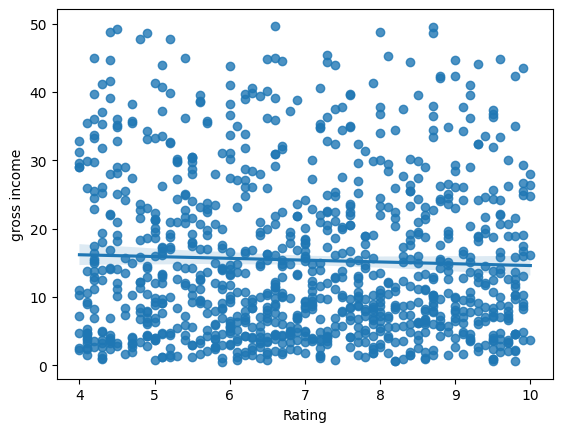

In [15]:
sns.regplot(x = df['Rating'], y = df['gross income'])
plt.show()

**Observation:**
- From the above plot, there doesn't seem to be a relationship between **Customer Ratings** and **Gross Income**.
- The trendline is almost flat, which means there is no relationship between **Customer Ratings** and **Gross Income**.

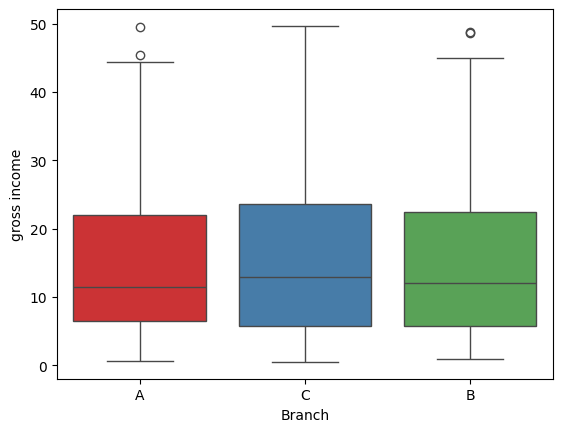

In [16]:
# Branch vs Gross Income
sns.boxplot(x = df['Branch'], y = df['gross income'], hue = df['Branch'], palette='Set1')
plt.show()

**Observations:**
- For Branch A, the median line for Gross Income is slightly above 10 and significantly lower than 20.
- For Branch C, the median line for Gross Income is slightly higher than that of Branch A.
- For Branch B, the median line for Gross Income is about the same as that of Branch A.
- Therefore, there doesn't seem to be much variation in Gross Income between the different branches.

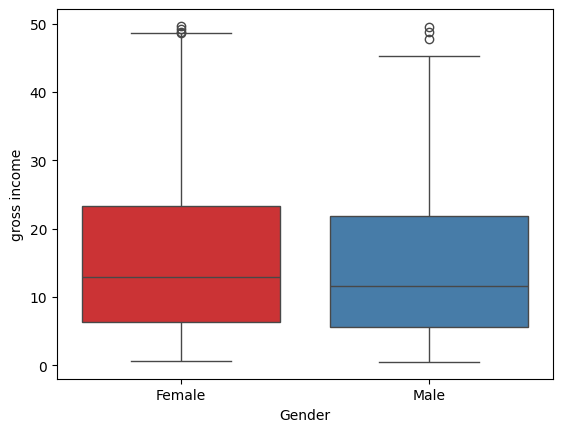

In [17]:
# Gender vs Gross Income
sns.boxplot(x = df['Gender'], y = df['gross income'], hue = df['Gender'], palette='Set1')
plt.show()

**Observations:**
- The Men and Women in this dataset spend about the same.
- At 75th Percentile, women spend higher than men. But on average, they seem to be pretty similar.

**Question 4:** Is there a noticeable time trend in gross income?

In [18]:
df.groupby(df.index).mean(numeric_only=True)

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,
2019-01-01,54.995833,6.454545,18.830083,395.431750,376.601667,4.761905,18.830083,6.583333
2019-01-02,44.635000,6.000000,11.580375,243.187875,231.607500,4.761905,11.580375,6.050000
2019-01-03,59.457500,4.625000,12.369813,259.766062,247.396250,4.761905,12.369813,8.112500
2019-01-04,51.743333,5.333333,12.886417,270.614750,257.728333,4.761905,12.886417,6.516667
2019-01-05,61.636667,4.583333,14.034458,294.723625,280.689167,4.761905,14.034458,7.433333
...,...,...,...,...,...,...,...,...
2019-03-26,42.972308,4.000000,7.188692,150.962538,143.773846,4.761905,7.188692,6.623077
2019-03-27,56.841000,4.500000,13.822950,290.281950,276.459000,4.761905,13.822950,6.760000
2019-03-28,45.525000,4.800000,10.616200,222.940200,212.324000,4.761905,10.616200,7.050000


In [19]:
df.groupby(df.index).mean(numeric_only=True).index

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-05', '2019-01-06', '2019-01-07', '2019-01-08',
               '2019-01-09', '2019-01-10', '2019-01-11', '2019-01-12',
               '2019-01-13', '2019-01-14', '2019-01-15', '2019-01-16',
               '2019-01-17', '2019-01-18', '2019-01-19', '2019-01-20',
               '2019-01-21', '2019-01-22', '2019-01-23', '2019-01-24',
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03', '2019-02-04', '2019-02-05',
               '2019-02-06', '2019-02-07', '2019-02-08', '2019-02-09',
               '2019-02-10', '2019-02-11', '2019-02-12', '2019-02-13',
               '2019-02-14', '2019-02-15', '2019-02-16', '2019-02-17',
               '2019-02-18', '2019-02-19', '2019-02-20', '2019-02-21',
               '2019-02-22', '2019-02-23', '2019-02-24', '2019-02-25',
      

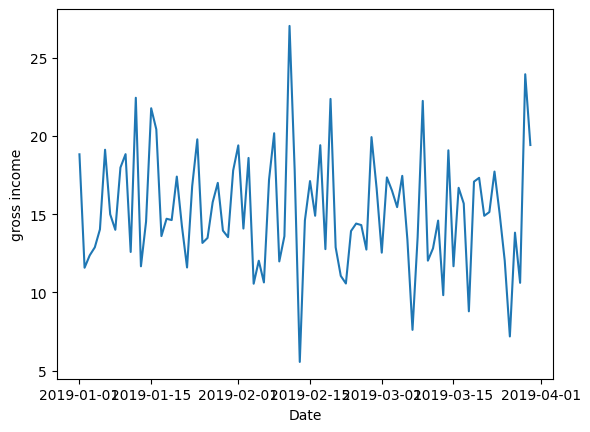

In [20]:
sns.lineplot(x = df.groupby(df.index).mean(numeric_only=True).index, 
             y = df.groupby(df.index).mean(numeric_only=True)['gross income'])
plt.show()

**Observation:**
- We don't notice any Time Trend in the gross income. It varies around the same mean.
- Some dates there are high gross income, and some dates there are low gross income. So, there doesn't seem to be any particular trend.

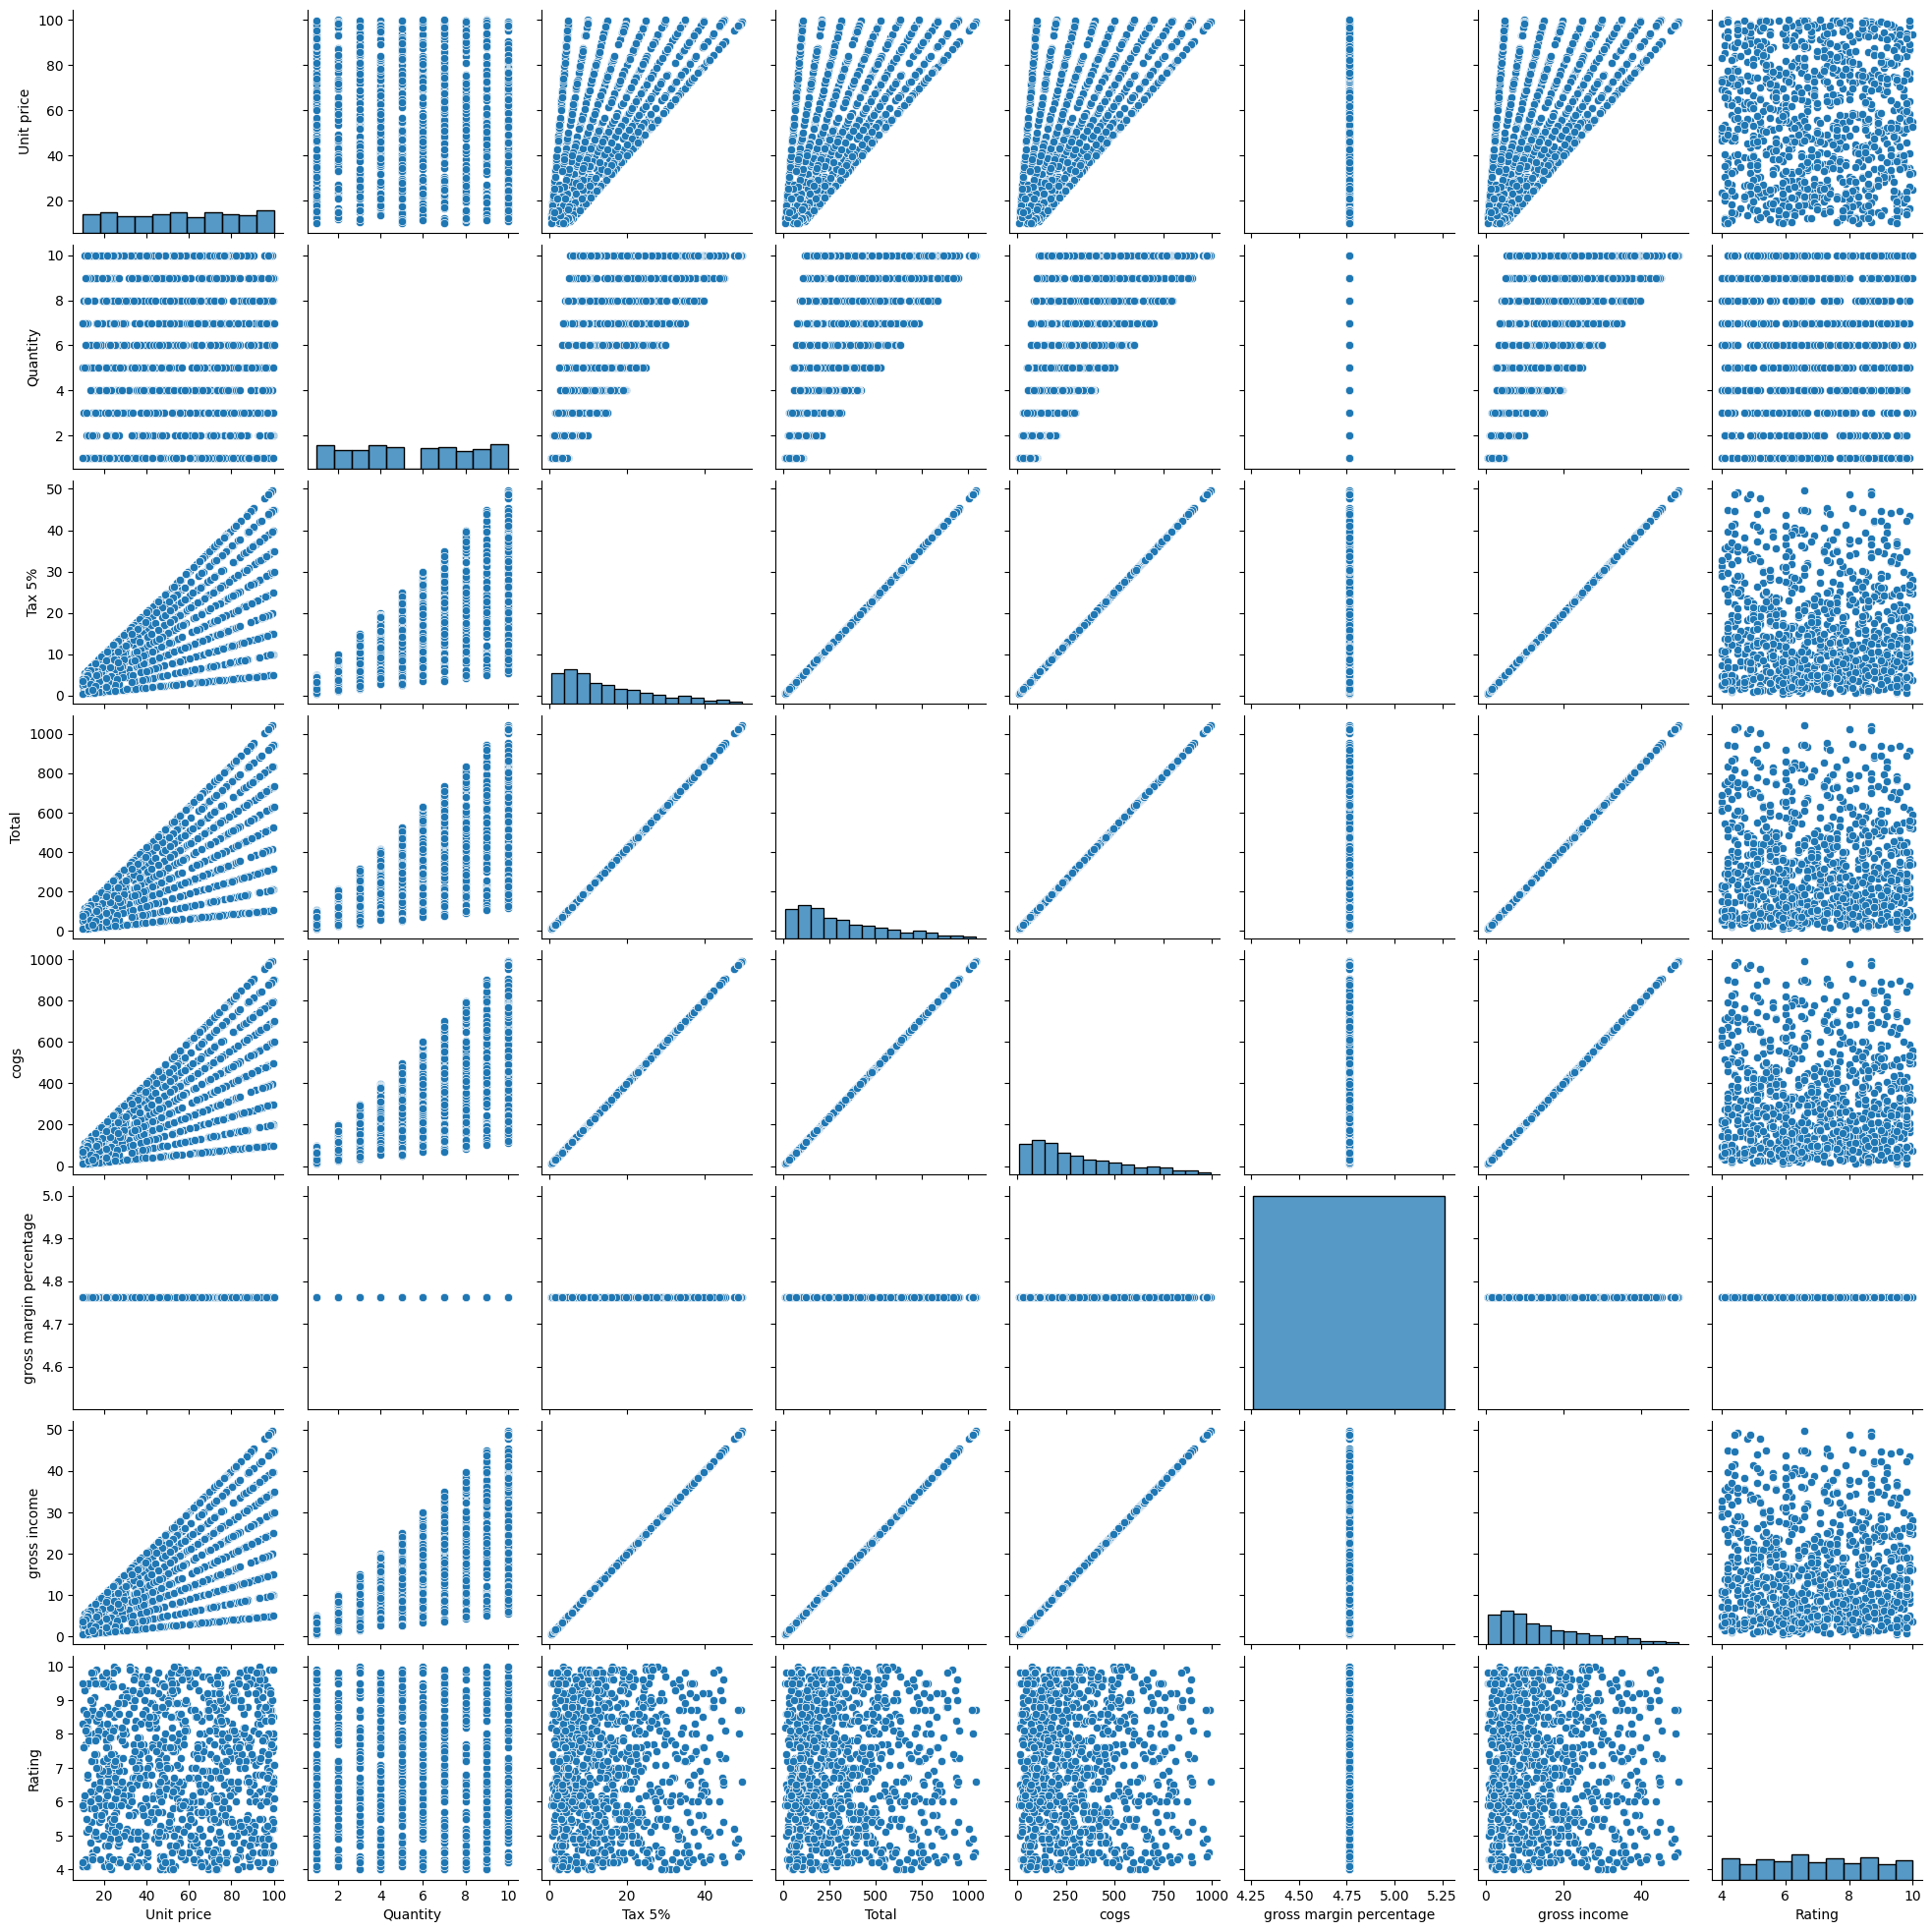

In [21]:
# Visualizing all the Univariate and Bivariate Plots
sns.pairplot(df.reset_index(drop=True))
plt.show()

### Task 4: Dealing With Duplicate Rows and Missing Values

In [22]:
# Total number of duplicate rows
print(df.duplicated().sum())

3


In [23]:
# These paticular rows are repeated more than once in our dataset
df[df.duplicated()==True]

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Time,Payment,cogs,gross margin percentage,gross income,Rating
Date,,,,,,,,,,,,,,,,
2019-02-18,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7.0,30.919,649.299,13:28,Cash,618.38,4.761905,30.919,6.6
2019-03-10,745-74-0715,A,Yangon,Normal,Male,Electronic accessories,NaN,2.0,5.803,121.863,20:46,Ewallet,116.06,4.761905,5.803,8.8
2019-01-26,452-04-8808,B,Mandalay,Normal,Male,Electronic accessories,87.08,NaN,30.478,640.038,15:17,Cash,609.56,4.761905,30.478,5.5


In [24]:
# Remove those duplicate rows
df.drop_duplicates(inplace=True)

In [25]:
print(df.duplicated().sum())

0


In [26]:
# Number of missing values per column
df.isna().sum()

Invoice ID                  0
Branch                      0
City                        0
Customer type              79
Gender                      0
Product line               43
Unit price                  6
Quantity                   19
Tax 5%                      0
Total                       0
Time                        0
Payment                     0
cogs                        0
gross margin percentage     0
gross income                0
Rating                      0
dtype: int64

In [27]:
# Ratio of missing values per column
df.isna().sum()/len(df)

Invoice ID                 0.000
Branch                     0.000
City                       0.000
Customer type              0.079
Gender                     0.000
Product line               0.043
Unit price                 0.006
Quantity                   0.019
Tax 5%                     0.000
Total                      0.000
Time                       0.000
Payment                    0.000
cogs                       0.000
gross margin percentage    0.000
gross income               0.000
Rating                     0.000
dtype: float64

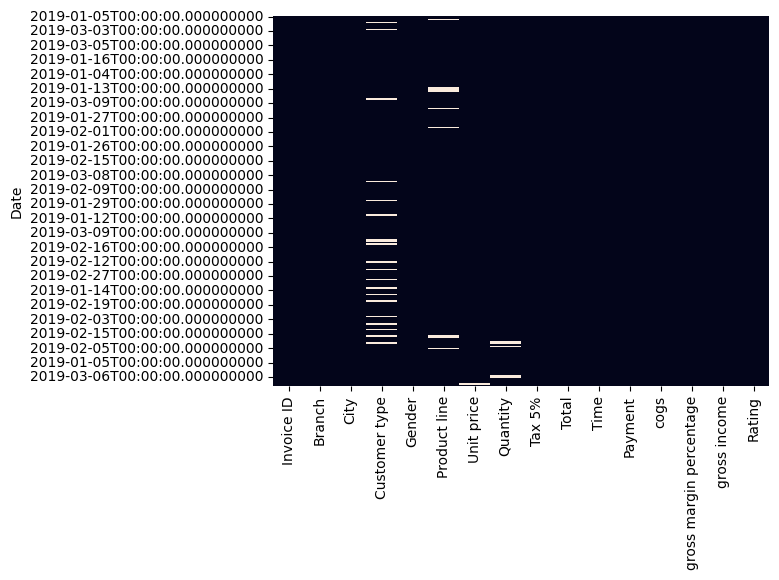

In [28]:
sns.heatmap(df.isnull(), cbar = False)
plt.show()

In [29]:
# Replace numeric missing values with the mean (For numeric columns)
df.fillna(df.mean(numeric_only=True), inplace = True)

In [30]:
# Mode for each column in the dataset
df.mode().iloc[0]

Invoice ID                         101-17-6199
Branch                                       A
City                                    Yangon
Customer type                           Normal
Gender                                  Female
Product line               Fashion accessories
Unit price                           55.700292
Quantity                                  10.0
Tax 5%                                   4.154
Total                                   87.234
Time                                     14:42
Payment                                Ewallet
cogs                                     83.08
gross margin percentage               4.761905
gross income                             4.154
Rating                                     6.0
Name: 0, dtype: object

In [31]:
# Replace categorical missing values with the mode (For categorical columns)
df.fillna(df.mode().iloc[0], inplace = True)

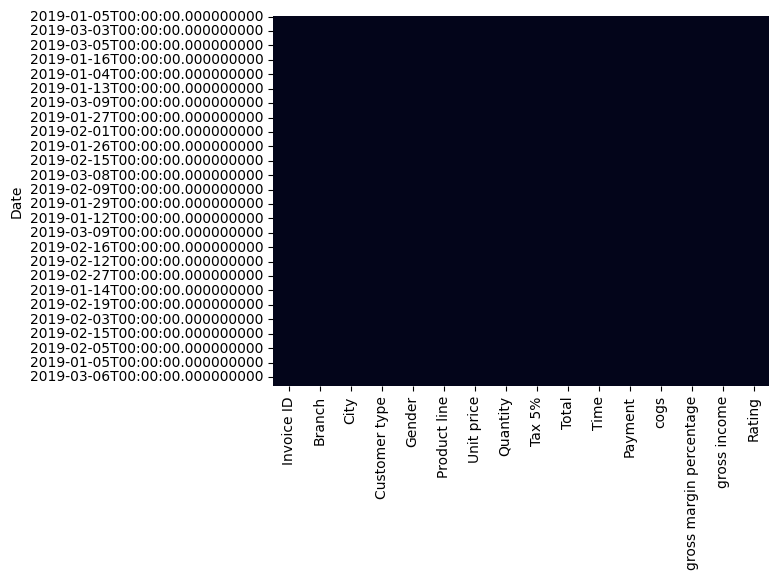

In [32]:
sns.heatmap(df.isnull(), cbar = False)
plt.show()

### Task 5: Correlation Analysis

In [33]:
print(np.corrcoef(df['gross income'], df['Rating']))

[[ 1.        -0.0364417]
 [-0.0364417  1.       ]]


In [34]:
print(np.corrcoef(df['gross income'], df['Rating'])[1][0])

-0.036441704997018376


In [35]:
# Rounding off to 2 decimal places
print(round(np.corrcoef(df['gross income'], df['Rating'])[1][0], 2))

-0.04


In [36]:
# Correlation Matrix
df.corr(numeric_only=True)

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
Unit price,1.000000,0.014786,0.629034,0.629034,0.629034,NaN,0.629034,-0.006601
Quantity,0.014786,1.000000,0.704067,0.704067,0.704067,NaN,0.704067,-0.021225
Tax 5%,0.629034,0.704067,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Total,0.629034,0.704067,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
cogs,0.629034,0.704067,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.629034,0.704067,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Rating,-0.006601,-0.021225,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000


In [37]:
# Rounding off to 2 decimal places
np.round(df.corr(numeric_only=True), 2)

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
Unit price,1.00,0.01,0.63,0.63,0.63,NaN,0.63,-0.01
Quantity,0.01,1.00,0.70,0.70,0.70,NaN,0.70,-0.02
Tax 5%,0.63,0.70,1.00,1.00,1.00,NaN,1.00,-0.04
Total,0.63,0.70,1.00,1.00,1.00,NaN,1.00,-0.04
cogs,0.63,0.70,1.00,1.00,1.00,NaN,1.00,-0.04
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.63,0.70,1.00,1.00,1.00,NaN,1.00,-0.04
Rating,-0.01,-0.02,-0.04,-0.04,-0.04,NaN,-0.04,1.00


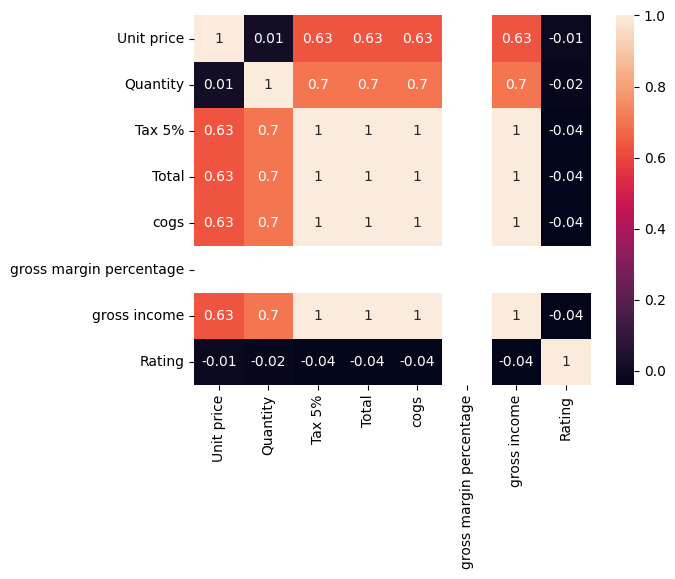

In [38]:
sns.heatmap(np.round(df.corr(numeric_only=True), 2), annot = True)
plt.show()

**Observation:**
- Rating has low correlation with every other variable in the dataset, i.e., The amount which a customer spends on their item is not correlated with their overall shopping experience rating.

---